**K.V. Kozenko, V.V.Gromyko, I.I. Beterov, I.I.Ryabtsev. Monte-Carlo simulation of performance of amplitude-robust CZ gate at finite temperature of atoms assuming infinite blockade and neglecting spontaneous decay. We simulate trajectories of the atomic motion in the trap. We use Rydopt package David F. Locher, Josias Old, Katharina Brechtelsbauer, Jakob Holschbach, Hans Peter Büchler, Sebastian Weber, Markus Müller, Multiqubit Rydberg Gates for Quantum Error Correction, arXiv:2512.00843**

In [1]:
import rydopt as ro
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt

C:\Users\Ilya Beterov\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import numpy as np
w0=1e-6 #beam waist in meters
lam=850e-9 #trap wavelength
z0=np.pi*(w0**2)/lam
cl= 299792458 #light velocity m/s
kB=1.380649e-23 #Boltzmann constant
MRb=87*1.660539e-27 #Rb 87 mass  
U0=1e-4 #trap potential
wr=np.sqrt(4*kB*U0/(MRb*w0**2)) #radial trap frequency in kHz
wz=np.sqrt(2*kB*U0/(MRb*z0**2)) #axial trap frequency in kHz

print("Radial frequency, %.5f kHz " % (wr*1e-3/(2*np.pi)))
print("Axial frequency, %.5f kHz " % (wz*1e-3/(2*np.pi)))

Radial frequency, 31.11771 kHz 
Axial frequency, 5.95335 kHz 


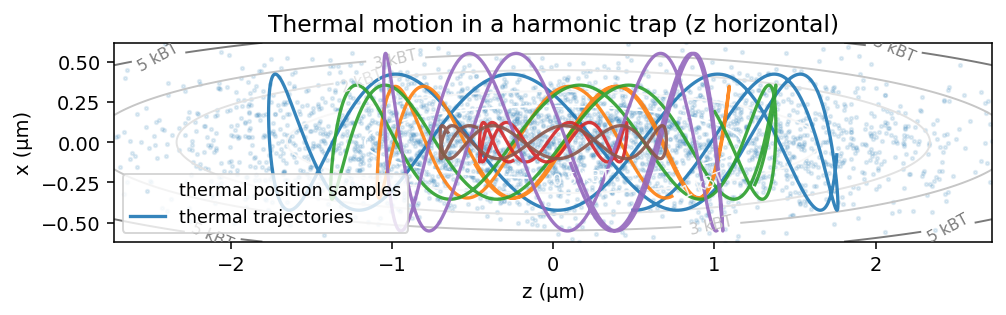

In [3]:
import numpy as np
import matplotlib.pyplot as plt

w0=1e-6 #beam waist in meters
lam=850e-9 #trap wavelength
z0=np.pi*(w0**2)/lam
cl= 299792458 #light velocity m/s
kB=1.380649e-23 #Boltzmann constant
m=87*1.660539e-27 #Rb 87 mass  
U0=1e-4 #trap potential
omega_x=np.sqrt(4*kB*U0/(MRb*w0**2)).item() #radial trap frequency in kHz
omega_z=np.sqrt(2*kB*U0/(MRb*z0**2)).item() #axial trap frequency in kHz



# -----------------------------
# Thermal motion in a harmonic trap (2D: x-z), with z on the HORIZONTAL axis
# and tight axis limits to avoid empty space.
# -----------------------------


# --- User parameters ---

T = 20e-6                 # K
#omega_x = 2*np.pi*28.3e3   # rad/s (tight direction)
#omega_z = 2*np.pi*4.9e3     # rad/s (weak direction)



# Simulation controls
t_end = 0.2e-3
n_t = 3500
seed = 3

# How many thermal trajectories to draw
n_traj = 6

# Thermal scatter cloud (equilibrium spatial distribution)
n_scatter = 3500

# Tight-limits controls
pad_frac = 0.12           # fractional padding around data bounds
percentile_clip = 99.5    # clip extreme scatter outliers for nicer framing

rng = np.random.default_rng(seed)

# -----------------------------
# Thermal widths (classical canonical equilibrium in harmonic trap)
# -----------------------------
sigma_x = np.sqrt(kB*T/(m*omega_x**2))
sigma_z = np.sqrt(kB*T/(m*omega_z**2))
sigma_v = np.sqrt(kB*T/m)

# Scatter samples from P(x,z) (Gaussian)
xs = rng.normal(0.0, sigma_x, size=n_scatter)
zs = rng.normal(0.0, sigma_z, size=n_scatter)

# Time grid
t = np.linspace(0.0, t_end, n_t)

def trajectory(x0, z0, vx0, vz0):
    """Analytic harmonic oscillator trajectory in each axis."""
    x = x0*np.cos(omega_x*t) + (vx0/omega_x)*np.sin(omega_x*t)
    z = z0*np.cos(omega_z*t) + (vz0/omega_z)*np.sin(omega_z*t)
    return x, z

# Generate multiple trajectories with thermal initial conditions
traj_x = []
traj_z = []
for _ in range(n_traj):
    x0 = rng.normal(0.0, sigma_x)
    z0 = rng.normal(0.0, sigma_z)
    vx0 = rng.normal(0.0, sigma_v)
    vz0 = rng.normal(0.0, sigma_v)
    x, z = trajectory(x0, z0, vx0, vz0)
    traj_x.append(x)
    traj_z.append(z)

traj_x = np.array(traj_x)  # shape (n_traj, n_t)
traj_z = np.array(traj_z)

# -----------------------------
# Choose tight plot limits based on scatter + trajectories
# (clip outliers for nicer framing)
# -----------------------------
all_x = np.concatenate([xs, traj_x.ravel()])
all_z = np.concatenate([zs, traj_z.ravel()])

x_lim = np.percentile(np.abs(all_x), percentile_clip)
z_lim = np.percentile(np.abs(all_z), percentile_clip)

x_lim *= (1.0 + pad_frac)
z_lim *= (1.0 + pad_frac)

# -----------------------------
# Background potential contours U(x,z) = 1/2 m (wx^2 x^2 + wz^2 z^2)
# We'll plot U/kBT as a function of (z,x) so that z is horizontal.
# -----------------------------
nx, nz = 240, 260
x_axis = np.linspace(-x_lim, x_lim, nx)
z_axis = np.linspace(-z_lim, z_lim, nz)

ZZ, XX = np.meshgrid(z_axis, x_axis)  # note: horizontal is Z, vertical is X
U_over_kBT = (0.5*m*(omega_x**2 * XX**2 + omega_z**2 * ZZ**2)) / (kB*T)

# -----------------------------
# Plot (z on horizontal axis, x on vertical axis)
# -----------------------------
plt.figure(figsize=(7.2, 5.2), dpi=140)

levels = [0.5, 1, 2, 3, 5, 8]
cs = plt.contour(ZZ*1e6, XX*1e6, U_over_kBT, levels=levels, cmap="Greys", linewidths=1.0)
plt.clabel(cs, fmt=lambda v: f"{v:g} kBT", fontsize=8)

# Scatter cloud (equilibrium position samples)
plt.scatter(zs*1e6, xs*1e6, s=3, alpha=0.12, color="tab:blue", label="thermal position samples")

# Trajectories
for i in range(n_traj):
    plt.plot(traj_z[i]*1e6, traj_x[i]*1e6, lw=1.7, alpha=0.9, label="thermal trajectories" if i == 0 else None)

plt.xlabel("z (µm)")  # horizontal
plt.ylabel("x (µm)")  # vertical
plt.title("Thermal motion in a harmonic trap (z horizontal)")

# Tight limits (avoid empty space)
plt.xlim(-z_lim*1e6, z_lim*1e6)
plt.ylim(-x_lim*1e6, x_lim*1e6)

# Use 'equal' if you want true spatial scaling; 'auto' fills the frame more.
plt.gca().set_aspect("equal", adjustable="box")

plt.legend(frameon=True, fontsize=9)
plt.tight_layout()
plt.savefig('AtomMotion.svg', format='svg')
plt.show()


In [4]:
def Rabi(r: float, z: float, lam: float, w0=1e-6):
    z0=np.pi*w0**2/lam
    return np.exp(-r**2/(w0**2))*np.exp(-z**2/(2*(z0**2)))

In [4]:
from rydopt.types import HamiltonianFunction
from rydopt.types import HamiltonianFunction
import jax.numpy as jnp  # jax.numpy should be imported after rydopt

class CZGateAsym:

    def __init__(self,     s1=1,  s2=1, f1=1, f2=1):
        self._s1 = s1
        self._s2 = s2
        self._f1 = f1
        self._f2 = f2
       
    def initial_basis_states(self) -> tuple[jnp.ndarray, ...]:
        return jnp.array([1,0], dtype=complex),   jnp.array([1,0], dtype=complex),  jnp.array([1,0,0], dtype=complex)

    def hamiltonian_functions_for_basis_states(self) -> tuple[HamiltonianFunction, ...]:
        def hamiltonian1(Delta: float, Xi: float, Omega: float) -> jnp.ndarray:
            """single-atom excitation with states 01,0e,0r"""
            s1=self._s1
            f1=self._f1
            return jnp.array(
                [
                   [0,Omega* jnp.exp(-1j * Xi)*0.5*s1],
                   [Omega* jnp.exp(1j * Xi)*0.5*s1,Delta*f1],
                                                          
                ]
            )
        def hamiltonian2(Delta: float, Xi: float, Omega: float) -> jnp.ndarray:
            """single-atom excitation with states 01,0e,0r"""
            
            s2=self._s2
            f2=self._f2
            return jnp.array(
                [
                   [0,Omega* jnp.exp(-1j * Xi)*0.5*s2],
                   [Omega* jnp.exp(1j * Xi)*s2*0.5,Delta*f2],
                                                          
                ]
            )
        def hamiltonian3(Delta: float, Xi: float, Omega: float) -> jnp.ndarray:
            """two-atom excitation with states 11,1e+e1,1r+r1,ee,er+re"""
           
            s1=self._s1
            s2=self._s2
            f1=self._f1
            f2=self._f2
            return jnp.array(
                    [
                      [0, Omega*jnp.exp(-1j * Xi)*0.5*s1, Omega*jnp.exp(-1j * Xi)*0.5*s2], 
                      [Omega*jnp.exp(1j * Xi)*0.5*s1, Delta*f1, 0], 
                      [Omega* jnp.exp(1j * Xi)*0.5*s2, 0,  Delta*f2] 
                    ]       
                )
        return hamiltonian1, hamiltonian2, hamiltonian3

    def process_fidelity(
        self, final_basis_states: tuple[jnp.ndarray, ...]
    ) -> jnp.ndarray:
        # Obtained diagonal gate matrix
        obtained_gate = jnp.array(
            [
                1,
                final_basis_states[0][0],
                final_basis_states[1][0],
                final_basis_states[2][0],
            ]
        )

        # Targeted diagonal gate matrix
        p = jnp.angle(obtained_gate[1]) 
        t = np.pi

        targeted_gate = jnp.stack(
            [
                1,
                jnp.exp(1j * p),
                jnp.exp(1j * p),
                jnp.exp(1j * (2 * p + t)),
            ]
        )
        return jnp.abs(jnp.vdot(targeted_gate, obtained_gate)) ** 2 / len(targeted_gate) ** 2

**Single-photon excitation: amplitude-robust pulses**

In [6]:
w0=1e-6 #beam waist in meters
lam=850e-9 #trap wavelength
z0=np.pi*(w0**2)/lam
cl= 299792458 #light velocity m/s
kB=1.380649e-23 #Boltzmann constant
MRb=87*1.660539e-27 #Rb 87 mass  
U0=1e-4 #trap potential
wr=np.sqrt(4*kB*U0/(MRb*w0**2)) #radial trap frequency in kHz
wz=np.sqrt(2*kB*U0/(MRb*z0**2)) #axial trap frequency in kHz
rng = np.random.default_rng()
Т=2e-5
N=10
sigma_xy=np.sqrt(kB*T/(MRb*wr**2))  #x and y spread
sigma_z=np.sqrt(kB*T/(MRb*wz**2)) #z spread
sigma_v=np.sqrt(kB*T/(MRb)) # velocity spread

    
t = rng.uniform(0, 2*np.pi/omega_z, size=(N, 2))  #time points during one cycle of trap motion
    # Initial conditions for two atoms (2) for N shots
x0  = rng.normal(0.0, sigma_xy, size=(N, 2))
y0  = rng.normal(0.0, sigma_xy, size=(N, 2))
z0  = rng.normal(0.0, sigma_z,  size=(N, 2))
vx0 = rng.normal(0.0, sigma_v,  size=(N, 2))
vy0 = rng.normal(0.0, sigma_v,  size=(N, 2))
vz0 = rng.normal(0.0, sigma_v,  size=(N, 2))

    # Harmonic evolution (analytic)
cr, sr = np.cos(wr * t), np.sin(wr * t)
cz, sz = np.cos(wz * t), np.sin(wz * t)

x  = x0 * cr + (vx0 / wr) * sr
y  = y0 * cr + (vy0 / wr) * sr
z  = z0 * cz + (vz0 / wz) * sz
vz = -z0 *wz * sz + vz0 * cz

r = np.sqrt(x*x + y*y)


In [7]:
x0

array([[ 2.93278444e-07,  1.59206949e-07],
       [-1.33236300e-08, -4.11394024e-08],
       [ 9.51708800e-08, -2.72955350e-07],
       [ 2.67452736e-08, -3.10686679e-07],
       [-7.92704861e-08,  2.96083102e-08],
       [-8.38188095e-08,  1.04144159e-07],
       [ 7.49392258e-08,  3.96778923e-08],
       [-2.94184039e-07, -1.31310594e-07],
       [-3.81580114e-07, -5.42572792e-10],
       [ 8.60966393e-08,  1.70619929e-07]])

In [ ]:
w0=1e-6 #beam waist in meters
lam=850e-9 #trap wavelength
z0=np.pi*(w0**2)/lam
cl= 299792458 #light velocity m/s
kB=1.380649e-23 #Boltzmann constant
MRb=87*1.660539e-27 #Rb 87 mass  
U0=1e-4 #trap potential
wr=np.sqrt(4*kB*U0/(MRb*w0**2)) #radial trap frequency in kHz
wz=np.sqrt(2*kB*U0/(MRb*z0**2)) #axial trap frequency in kHz
pulse_ansatz_const = ro.pulses.PulseAnsatz(detuning_ansatz=ro.pulses.const, phase_ansatz=ro.pulses.lin_sin_cos_crab, rabi_ansatz=ro.pulses.const)
d=19.16385937372734
initial_params =  (1, [-0.37987234*d ], [0.4383259*d, 0.13563877, -0.5107974, -1.18969017, 0.03092594, 0.04407889, -0.90402676, 0.16778956, 0.14164386, 0.53182775, -0.45699411, -1.04176518, 0.13357412, 0.88517945, -0.61091495], [0.91540583*d])
Tlist=np.linspace(1e-6,1e-5,6)
rng = np.random.default_rng()
RobustTdepS=[]
N = 200 #data size

for j in range(len(Tlist)):
    T=Tlist[j] #list of temperatures
    sigma_xy=np.sqrt(kB*T/(MRb*wr**2))  #x and y spread
    sigma_z=np.sqrt(kB*T/(MRb*wz**2)) #z spread
    sigma_v=np.sqrt(kB*T/(MRb)) # velocity spread

    
    t = rng.uniform(0, 2*np.pi/omega_z, size=(N, 2))  #time points during one cycle of trap motion
    # Initial conditions for two atoms (2) for N shots
    x0  = rng.normal(0.0, sigma_xy, size=(N, 2))
    y0  = rng.normal(0.0, sigma_xy, size=(N, 2))
    z0  = rng.normal(0.0, sigma_z,  size=(N, 2))
    vx0 = rng.normal(0.0, sigma_v,  size=(N, 2))
    vy0 = rng.normal(0.0, sigma_v,  size=(N, 2))
    vz0 = rng.normal(0.0, sigma_v,  size=(N, 2))

    # Harmonic evolution (analytic)
    cr, sr = np.cos(wr * t), np.sin(wr * t)
    cz, sz = np.cos(wz * t), np.sin(wz * t)

    x  = x0 * cr + (vx0 / wr) * sr
    y  = y0 * cr + (vy0 / wr) * sr
    z  = z0 * cz + (vz0 / wz) * sz
    vz = -z0 *wz * sz + vz0 * cz

    r = np.sqrt(x*x + y*y)

    Radial1 = r[:, 0]
    Axial1 = z[:, 0]
    Radial2 = r[:, 1]
    Axial2 = z[:, 1]
    Vz1= vz[:, 0]
    Vz2= vz[:, 1]
    Doppler1=Vz1*1e-6*2*np.pi*(1/(297e-9))/10
    Doppler2=Vz2*1e-6*2*np.pi*(1/(297e-9))/10
    
    Scaling1=Rabi(Radial1,Axial1,297e-9)
    Scaling2=Rabi(Radial2,Axial2,297e-9)

    Detuning1=(initial_params[1]+Doppler1)/initial_params[1]
    Detuning2=(initial_params[1]+Doppler2)/initial_params[1]
    FRobustT=[]
    print("j= %.i " % j)
    for i in range(len(Scaling1)):
        gate = CZGateAsym(s1=Scaling1[i] ,s2=Scaling2[i],f1= Detuning1[i],f2= Detuning2[i])
        pulse_params  = initial_params[0],initial_params[1],initial_params[2],initial_params[3],
        time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz_const, pulse_params)
        FRobustT.append(1-gate.process_fidelity(time_evolved_basis_states).item())
        print(i)
    RobustTdepS.append(np.mean(FRobustT).item())
RobustTdepS

In [5]:
RobustTdepS=[5.887358813038035e-05,
 0.0001641744535158346,
 0.0003636028337316544,
 0.0005145796910047983,
 0.0007480890305502358,
 0.0010432722062928884]

In [ ]:
RobustTdepS

In [ ]:
w0=1e-6 #beam waist in meters
lam=850e-9 #trap wavelength
z0=np.pi*(w0**2)/lam
cl= 299792458 #light velocity m/s
kB=1.380649e-23 #Boltzmann constant
MRb=87*1.660539e-27 #Rb 87 mass  
U0=1e-4 #trap potential
wr=np.sqrt(4*kB*U0/(MRb*w0**2)) #radial trap frequency in kHz
wz=np.sqrt(2*kB*U0/(MRb*z0**2)) #axial trap frequency in kHz


pulse_ansatz = ro.pulses.PulseAnsatz(
    detuning_ansatz=ro.pulses.const,
    phase_ansatz=ro.pulses.sin_crab,
    rabi_ansatz=ro.pulses.softbox_seventh_order_smoothstep,
)
d=4.058348807763706
initial_params=(1, [-0.09393892*d ], [0.73884332, 0.77225565], [2.09722135*d , 0.19713572])


#pulse_ansatz_const = ro.pulses.PulseAnsatz(detuning_ansatz=ro.pulses.const, phase_ansatz=ro.pulses.lin_sin_cos_crab, rabi_ansatz=ro.pulses.const)
#d=19.16385937372734
#initial_params =  (1, [-0.37987234*d ], [0.4383259*d, 0.13563877, -0.5107974, -1.18969017, 0.03092594, 0.04407889, -0.90402676, 0.16778956, 0.14164386, 0.53182775, -0.45699411, -1.04176518, 0.13357412, 0.88517945, -0.61091495], [0.91540583*d])
Tlist=np.linspace(1e-6,1e-5,6)
rng = np.random.default_rng()
FTOTdepS=[]
N = 100 #data size

for j in range(len(Tlist)):
    T=Tlist[j] #list of temperatures
    sigma_xy=np.sqrt(kB*T/(MRb*wr**2))  #x and y spread
    sigma_z=np.sqrt(kB*T/(MRb*wz**2)) #z spread
    sigma_v=np.sqrt(kB*T/(MRb)) # velocity spread

    
    t = rng.uniform(0, 2*np.pi/omega_z, size=(N, 2))  #time points during one cycle of trap motion
    # Initial conditions for two atoms (2) for N shots
    x0  = rng.normal(0.0, sigma_xy, size=(N, 2))
    y0  = rng.normal(0.0, sigma_xy, size=(N, 2))
    z0  = rng.normal(0.0, sigma_z,  size=(N, 2))
    vx0 = rng.normal(0.0, sigma_v,  size=(N, 2))
    vy0 = rng.normal(0.0, sigma_v,  size=(N, 2))
    vz0 = rng.normal(0.0, sigma_v,  size=(N, 2))

    # Harmonic evolution (analytic)
    cr, sr = np.cos(wr * t), np.sin(wr * t)
    cz, sz = np.cos(wz * t), np.sin(wz * t)

    x  = x0 * cr + (vx0 / wr) * sr
    y  = y0 * cr + (vy0 / wr) * sr
    z  = z0 * cz + (vz0 / wz) * sz
    vz = -z0 *wz * sz + vz0 * cz

    r = np.sqrt(x*x + y*y)

    
    Radial1 = r[:, 0]
    Axial1 = z[:, 0]
    Radial2 = r[:, 1]
    Axial2 = z[:, 1]
    Vz1= vz[:, 0]
    Vz2= vz[:, 1]
    Doppler1=Vz1*1e-6*2*np.pi*(1/(297e-9))/10
    Doppler2=Vz2*1e-6*2*np.pi*(1/(297e-9))/10
    
    Scaling1=Rabi(Radial1,Axial1,297e-9)
    Scaling2=Rabi(Radial2,Axial2,297e-9)

    Detuning1=(initial_params[1]+Doppler1)/initial_params[1]
    Detuning2=(initial_params[1]+Doppler2)/initial_params[1]
    FRobustT=[]
    print("j= %.i " % j)
    for i in range(len(Scaling1)):
        gate = CZGateAsym(s1=Scaling1[i] ,s2=Scaling2[i],f1= Detuning1[i],f2= Detuning2[i])
        pulse_params  = initial_params[0],initial_params[1],initial_params[2],initial_params[3],
        time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz, pulse_params)
        FRobustT.append(1-gate.process_fidelity(time_evolved_basis_states).item())
        print(i)
    FTOTdepS.append(np.mean(FRobustT).item())
FTOTdepS

In [6]:
FTOTdepS=[0.00026876079518729947,
 0.0017028249728544098,
 0.004259092244838593,
 0.006183407661491693,
 0.012586670747115013,
 0.017011722211403645]

In [7]:
Tlist=np.linspace(1e-6,1e-5,6)

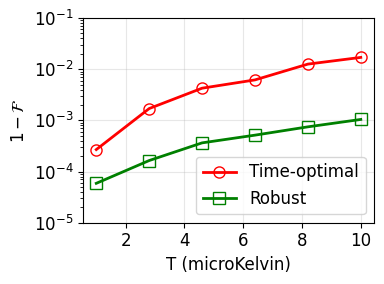

In [15]:
fig, ax = plt.subplots(figsize=(4, 3))
plt.rcParams.update({'font.size': 12})
plt.rcParams['lines.linewidth'] = 2
# Plot the first series

ax.plot(Tlist*1e6, FTOTdepS, label='Time-optimal', color='red', marker='o', mfc='none', markersize=8)
# Plot the third series
ax.plot(Tlist*1e6, RobustTdepS, label='Robust', color='green', marker='s', mfc='none', markersize=8)


# Add labels, title, and a legend for clarity
ax.set_xlabel("T (microKelvin)")
ax.set_ylabel(r"$1-\mathcal{F}$")
ax.set_yscale('log')
ax.set_ylim(1e-5,1e-1)
ax.legend() # Displays the labels defined in the scatter calls
fig.tight_layout()
ax.grid(alpha=0.3)
plt.savefig('RobustnessMonteCarloSinglePhoton.svg', format='svg')
# Display the plot
plt.show()

**Now we analayze robustness of two-photon scheme to asymmetry**

In [11]:
from sympy import symbols, Matrix 
import sympy as sp
import numpy as np
from sympy.physics.quantum import TensorProduct
Omega1S, Omega1SC, Omega1P, Omega1PC, Delta1P, Delta1, V, DecayP, DecayR= symbols('Omega1S, Omega1SC, Omega1P, Omega1PC, Delta1P, Delta1, V, DecayP, DecayR')
Omega2S, Omega2SC, Omega2P, Omega2PC, Delta2P, Delta2 = symbols('Omega2S, Omega2SC, Omega2P, Omega2PC, Delta2P, Delta2  ')
Drive1 = Matrix( [
                   [0,Omega1P*0.5,0],
                   [Omega1PC*0.5,-Delta1P-1j*0.5*DecayP,Omega1S*0.5],
                   [0,Omega1SC*0.5,Delta1-1j*0.5*DecayR]
                                                          
                ])
Drive2 = Matrix( [
                   [0,Omega2P*0.5,0],
                   [Omega2PC*0.5,-Delta2P-1j*0.5*DecayP,Omega2S*0.5],
                   [0,Omega2SC*0.5,Delta2-1j*0.5*DecayR]
                                                          
                ])

In [23]:
Drive1

Matrix([
[           0,             0.5*Omega1P,                      0],
[0.5*Omega1PC, -0.5*I*DecayP - Delta1P,            0.5*Omega1S],
[           0,            0.5*Omega1SC, -0.5*I*DecayR + Delta1]])

In [27]:
Drive2

Matrix([
[           0,             0.5*Omega2P,                      0],
[0.5*Omega2PC, -0.5*I*DecayP - Delta2P,            0.5*Omega2S],
[           0,            0.5*Omega2SC, -0.5*I*DecayR + Delta2]])

In [24]:
Identity3= Matrix(np.eye(3))
expr=TensorProduct(Drive2, Identity3)+TensorProduct(Identity3, Drive1)
expr

Matrix([
[           0,                 0.5*Omega1P,                          0,                 0.5*Omega2P,                                         0,                                                       0,                          0,                                                       0,                                       0],
[0.5*Omega1PC, -0.5*I*DecayP - 1.0*Delta1P,                0.5*Omega1S,                           0,                               0.5*Omega2P,                                                       0,                          0,                                                       0,                                       0],
[           0,                0.5*Omega1SC, -0.5*I*DecayR + 1.0*Delta1,                           0,                                         0,                                             0.5*Omega2P,                          0,                                                       0,                                       0],
[0.5*Om

In [29]:
for i in range(expr.rows):
    print(list(expr.row(i)))

[0, 0.5*Omega1P, 0, 0.5*Omega2P, 0, 0, 0, 0, 0]
[0.5*Omega1PC, -0.5*I*DecayP - 1.0*Delta1P, 0.5*Omega1S, 0, 0.5*Omega2P, 0, 0, 0, 0]
[0, 0.5*Omega1SC, -0.5*I*DecayR + 1.0*Delta1, 0, 0, 0.5*Omega2P, 0, 0, 0]
[0.5*Omega2PC, 0, 0, -0.5*I*DecayP - 1.0*Delta2P, 0.5*Omega1P, 0, 0.5*Omega2S, 0, 0]
[0, 0.5*Omega2PC, 0, 0.5*Omega1PC, -1.0*I*DecayP - 1.0*Delta1P - 1.0*Delta2P, 0.5*Omega1S, 0, 0.5*Omega2S, 0]
[0, 0, 0.5*Omega2PC, 0, 0.5*Omega1SC, -0.5*I*DecayP - 0.5*I*DecayR + 1.0*Delta1 - 1.0*Delta2P, 0, 0, 0.5*Omega2S]
[0, 0, 0, 0.5*Omega2SC, 0, 0, -0.5*I*DecayR + 1.0*Delta2, 0.5*Omega1P, 0]
[0, 0, 0, 0, 0.5*Omega2SC, 0, 0.5*Omega1PC, -0.5*I*DecayP - 0.5*I*DecayR - 1.0*Delta1P + 1.0*Delta2, 0.5*Omega1S]
[0, 0, 0, 0, 0, 0.5*Omega2SC, 0, 0.5*Omega1SC, -1.0*I*DecayR + 1.0*Delta1 + 1.0*Delta2]


In [25]:
print(Drive1)

Matrix([[0, 0.5*Omega1P, 0], [0.5*Omega1PC, -0.5*I*DecayP - Delta1P, 0.5*Omega1S], [0, 0.5*Omega1SC, -0.5*I*DecayR + Delta1]])


**Asymmetric two-photon gate with infinite blockade strength**

In [5]:
from rydopt.types import HamiltonianFunction
class CZGateTwoPhotonAsymm:

    def __init__(self, Delta1P: float,  Delta2P :float,  DecayP=0, DecayR=0, s1=1, s2=1, p1=1, p2=1, f1=1, f2=1):
        self._Delta1P = Delta1P
        self._Delta2P = Delta2P
        self._DecayP = DecayP
        self._DecayR = DecayR
        self._s1=s1 #relative Rabi frequency OmegaS
        self._s2=s2
        self._p1=p1 #relative Rabi frequency OmegaP
        self._p2=p2
        self._f1=f1 #relative two-photon detuning
        self._f2=f2
        
    def initial_basis_states(self) -> tuple[jnp.ndarray, ...]:
        return jnp.array([1,0,0], dtype=complex), jnp.array([1,0,0], dtype=complex), jnp.array([1,0,0,0,0,0,0,0], dtype=complex)

    def hamiltonian_functions_for_basis_states(self) -> tuple[HamiltonianFunction, ...]:
        
        def hamiltonian1(Delta: float, Xi: float, Omega: float) -> jnp.ndarray:
            """single-atom excitation with states 01,0e,0r"""
            s1=self._s1
            p1=self._p1
            f1=self._f1
            Delta1=Delta*f1
            Delta1P=self._Delta1P
            DecayP=self._DecayP
            DecayR=self._DecayR

            
            Omega1S=jnp.sqrt(2*Delta1P*Omega)*jnp.exp(-1j*Xi)*s1
            Omega1SC=jnp.sqrt(2*Delta1P*Omega)*jnp.exp(+1j*Xi)*s1
            
            Omega1P=jnp.sqrt(2*Delta1P*Omega)*p1
            Omega1PC=jnp.sqrt(2*Delta1P*Omega)*p1
            
              
            return jnp.array(
            [
                    [0, 0.5*Omega1P, 0], 
                    [0.5*Omega1PC, -0.5*1j*DecayP - Delta1P, 0.5*Omega1S], 
                    [0, 0.5*Omega1SC, -0.5*1j*DecayR + Delta1]                                    
                ]
            )

        def hamiltonian2(Delta: float, Xi: float, Omega: float) -> jnp.ndarray:
            """single-atom excitation with states 01,0e,0r"""
            s2=self._s2
            p2=self._p2
            f2=self._f2
            Delta2=Delta*f2
            Delta2P=self._Delta2P
            DecayP=self._DecayP
            DecayR=self._DecayR

        
            Omega2S=jnp.sqrt(2*Delta2P*Omega)*jnp.exp(-1j * Xi)*s2
            Omega2SC=jnp.sqrt(2*Delta2P*Omega)*jnp.exp(1j * Xi)*s2
            
            Omega2P=jnp.sqrt(2*Delta2P*Omega)*p2
            Omega2PC=jnp.sqrt(2*Delta2P*Omega)*p2
            return jnp.array(
                [
                    [0, 0.5*Omega2P, 0], 
                    [0.5*Omega2PC, -0.5*1j*DecayP - Delta2P, 0.5*Omega2S], 
                    [0, 0.5*Omega2SC, -0.5*1j*DecayR + Delta2]                                    
                ]                                           
                
            )
        def hamiltonian3(Delta: float, Xi: float, Omega: float) -> jnp.ndarray:
            """two-atom excitation with states 11,1e+e1,1r+r1,ee,er+re,rr"""
            f1=self._f1
            f2=self._f2
            Delta1=Delta*f1
            Delta2=Delta*f2
            Delta1P=self._Delta1P
            Delta2P=self._Delta2P
            DecayP=self._DecayP
            DecayR=self._DecayR
            s1=self._s1
            p1=self._p1
            s2=self._s2
            p2=self._p2

            
            Omega1S=jnp.sqrt(2*Delta1P*Omega)*jnp.exp(-1j*Xi)*s1
            Omega1SC=jnp.sqrt(2*Delta1P*Omega)*jnp.exp(1j* Xi)*s1
            
            Omega1P=jnp.sqrt(2*Delta1P*Omega)*p1
            Omega1PC=jnp.sqrt(2*Delta1P*Omega)*p1
            
            Omega2S=jnp.sqrt(2*Delta2P*Omega)*jnp.exp(-1j * Xi )*s2
            Omega2SC=jnp.sqrt(2*Delta2P*Omega)*jnp.exp(1j * Xi )*s2
            
            Omega2P=jnp.sqrt(2*Delta2P*Omega)*p2
            Omega2PC=jnp.sqrt(2*Delta2P*Omega)*p2
            
            return jnp.array([
                [0, 0.5*Omega1P, 0, 0.5*Omega2P, 0, 0, 0, 0],
                [0.5*Omega1PC, -0.5*1j*DecayP - 1.0*Delta1P, 0.5*Omega1S, 0, 0.5*Omega2P, 0, 0, 0],
                [0, 0.5*Omega1SC, -0.5*1j*DecayR + Delta1, 0, 0, 0.5*Omega2P, 0, 0],
                [0.5*Omega2PC, 0, 0, -0.5*1j*DecayP - 1.0*Delta2P, 0.5*Omega1P, 0, 0.5*Omega2S, 0],
                [0, 0.5*Omega2PC, 0, 0.5*Omega1PC, -1.0*1j*DecayP - 1.0*Delta1P - 1.0*Delta2P, 0.5*Omega1S, 0, 0.5*Omega2S],
                [0, 0, 0.5*Omega2PC, 0, 0.5*Omega1SC, -0.5*1j*DecayP - 0.5*1j*DecayR + 1.0*Delta1 - 1.0*Delta2P, 0, 0],
                [0, 0, 0, 0.5*Omega2SC, 0, 0, -0.5*1j*DecayR + 1.0*Delta2, 0.5*Omega1P],
                [0, 0, 0, 0, 0.5*Omega2SC, 0, 0.5*Omega1PC, -0.5*1j*DecayP - 0.5*1j*DecayR - 1.0*Delta1P + 1.0*Delta2]
    
            ]

              
            )
        return hamiltonian1, hamiltonian2,hamiltonian3
 
    
    def process_fidelity(
        self, final_basis_states: tuple[jnp.ndarray, ...]
    ) -> jnp.ndarray:
        # Obtained diagonal gate matrix
        obtained_gate = jnp.array(
            [
                1,
                final_basis_states[0][0],
                final_basis_states[1][0],
                final_basis_states[2][0],
            ]
        )

        # Targeted diagonal gate matrix
        p1 = jnp.angle(obtained_gate[1]) 
        p2 = jnp.angle(obtained_gate[2]) 
        t = np.pi
        targeted_gate = jnp.stack(
            [
                1,
                jnp.exp(1j * p1),
                jnp.exp(1j * p2),
                jnp.exp(1j * ( p1+p2 + t)),
            ]
        )
        return jnp.abs(jnp.vdot(targeted_gate, obtained_gate)) ** 2 / len(targeted_gate) ** 2

**Asymmetric smooth robust gate**

In [6]:
d=22.662134135960255
pulse_ansatz_to = ro.pulses.PulseAnsatz(detuning_ansatz=ro.pulses.const,
                                        phase_ansatz=ro.pulses.lin_sin_cos_crab,
                                        rabi_ansatz=ro.pulses.softbox_seventh_order_smoothstep)
initial_params  =  (1, [0.40433569*d], [0.01959632*d, 0.80582318, -1.29913162, 0.24595796, 1.75011831, 0.06425968, -0.15430385, 0.10287453, -0.18786168, -0.1484231, 0.2266793, -0.02549104, -0.6134942, 0.8116914, 0.10364234, -0.34698707, -0.57748581, -0.11806264, 0.50882035, -0.2240126, -0.58173406], [0.99964949*d , 0.25690718])
gate = CZGateTwoPhotonAsymm(2*np.pi*500,2*np.pi*500,s1=1 ,s2=1.0,p1=1 ,p2=1.0, f1=1.0,f2=1.0)
#gate = ro.gates.TwoQubitGate(phi=None, theta=np.pi, Vnn=float("inf"), decay=0.0)
time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz_to, initial_params)
1-gate.process_fidelity(time_evolved_basis_states).item()

0.0003369187687914943

**Asymmetric const robust gate**

In [8]:
pulse_ansatz_const = ro.pulses.PulseAnsatz(detuning_ansatz=ro.pulses.const, phase_ansatz=ro.pulses.lin_sin_cos_crab, rabi_ansatz=ro.pulses.const)
d=19.16385937372734
const_end_new_metrics_params =  (1, [-0.37987234*d ], [0.4383259*d, 0.13563877, -0.5107974, -1.18969017, 0.03092594, 0.04407889, -0.90402676, 0.16778956, 0.14164386, 0.53182775, -0.45699411, -1.04176518, 0.13357412, 0.88517945, -0.61091495], [0.91540583*d])
gate = CZGateTwoPhotonAsymm(2*np.pi*500,2*np.pi*500,s1=1 ,s2=1.05,p1=1  ,p2=1.05)
#gate = ro.gates.TwoQubitGate(phi=None, theta=np.pi, Vnn=float("inf"), decay=0.0)
time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz_const, const_end_new_metrics_params )
1-gate.process_fidelity(time_evolved_basis_states).item()

0.0036269693654088497

**Asymmetric smooth time-optimal gate**

In [9]:
pulse_ansatz = ro.pulses.PulseAnsatz(
    detuning_ansatz=ro.pulses.const,
    phase_ansatz=ro.pulses.sin_crab,
    rabi_ansatz=ro.pulses.softbox_seventh_order_smoothstep,
)
d=4.058348807763706
initial_params=(1, [-0.09393892*d], [0.73884332, 0.77225565], [2.09722135*d, 0.19713572])
gate = CZGateTwoPhotonAsymm(2*np.pi*500,2*np.pi*500,s1=1.  ,s2=1.05,p1=1.0 ,p2=1.05 )
#gate = ro.gates.TwoQubitGate(phi=None, theta=np.pi, Vnn=float("inf"), decay=0.0)
time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz, initial_params)
1-gate.process_fidelity(time_evolved_basis_states).item()

0.01047416784935884

**Asymmetric constant Rabi frequency robust gate**

In [10]:
d=19.16385937372734
pulse_ansatz  = ro.pulses.PulseAnsatz(
    detuning_ansatz=ro.pulses.const, 
    phase_ansatz=ro.pulses.lin_sin_cos_crab, 
    rabi_ansatz=ro.pulses.const)
optimized_params  =  (d, [-0.37987234 ], [0.43832597, 0.13563877, -0.5107974, -1.18969017, 0.03092594, 0.04407889, -0.90402676, 0.16778956, 0.14164386, 0.53182775, -0.45699411, -1.04176518, 0.13357412, 0.88517945, -0.61091495], [0.91540583])
gate = CZGateTwoPhotonAsymm(2*np.pi*500,2*np.pi*500,s1=1.04 ,s2=0.97,p1=1.03 ,p2=0.98 )
#gate = ro.gates.TwoQubitGate(phi=None, theta=np.pi, Vnn=float("inf"), decay=0.0)
time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz, optimized_params)
1-gate.process_fidelity(time_evolved_basis_states).item()

0.0007578243795962614

**Monte-Carlo simulation for two-photon excitation at 480 nm and 780 nm with Doppler**

***Amplitude-robust***

In [ ]:
w0=1e-6 #beam waist in meters
lam=850e-9 #trap wavelength
z0=np.pi*(w0**2)/lam
cl= 299792458 #light velocity m/s
kB=1.380649e-23 #Boltzmann constant
MRb=87*1.660539e-27 #Rb 87 mass  
U0=1e-4 #trap potential
wr=np.sqrt(4*kB*U0/(MRb*w0**2)) #radial trap frequency in kHz
wz=np.sqrt(2*kB*U0/(MRb*z0**2)) #axial trap frequency in kHz
d=22.662134135960255
pulse_ansatz_to = ro.pulses.PulseAnsatz(detuning_ansatz=ro.pulses.const,
                                        phase_ansatz=ro.pulses.lin_sin_cos_crab,
                                        rabi_ansatz=ro.pulses.softbox_seventh_order_smoothstep)
initial_params  =  (1, [0.40433569*d], [0.01959632*d, 0.80582318, -1.29913162, 0.24595796, 1.75011831, 0.06425968, -0.15430385, 0.10287453, -0.18786168, -0.1484231, 0.2266793, -0.02549104, -0.6134942, 0.8116914, 0.10364234, -0.34698707, -0.57748581, -0.11806264, 0.50882035, -0.2240126, -0.58173406], [0.99964949*d , 0.25690718])
Tlist=np.linspace(1e-6,1e-5,6)
rng = np.random.default_rng()
RobustTdep480D=[]
N = 200 #data size

for j in range(len(Tlist)):
    T=Tlist[j] #list of temperatures
    sigma_xy=np.sqrt(kB*T/(MRb*wr**2))  #x and y spread
    sigma_z=np.sqrt(kB*T/(MRb*wz**2)) #z spread
    sigma_v=np.sqrt(kB*T/(MRb)) # velocity spread

    
    t = rng.uniform(0, 2*np.pi/omega_z, size=(N, 2))  #time points during one cycle of trap motion
    # Initial conditions for two atoms (2) for N shots
    x0  = rng.normal(0.0, sigma_xy, size=(N, 2))
    y0  = rng.normal(0.0, sigma_xy, size=(N, 2))
    z0  = rng.normal(0.0, sigma_z,  size=(N, 2))
    vx0 = rng.normal(0.0, sigma_v,  size=(N, 2))
    vy0 = rng.normal(0.0, sigma_v,  size=(N, 2))
    vz0 = rng.normal(0.0, sigma_v,  size=(N, 2))

    # Harmonic evolution (analytic)
    cr, sr = np.cos(wr * t), np.sin(wr * t)
    cz, sz = np.cos(wz * t), np.sin(wz * t)

    x  = x0 * cr + (vx0 / wr) * sr
    y  = y0 * cr + (vy0 / wr) * sr
    z  = z0 * cz + (vz0 / wz) * sz
    vz = -z0 *wz * sz + vz0 * cz

    r = np.sqrt(x*x + y*y)

    Radial1 = r[:, 0]
    Axial1 = z[:, 0]
    Radial2 = r[:, 1]
    Axial2 = z[:, 1]
    Vz1= vz[:, 0]
    Vz2= vz[:, 1]
    Doppler1=Vz1*1e-6*2*np.pi*(1/(480e-9)-1/(780e-9)) 
    Doppler2=Vz2*1e-6*2*np.pi*(1/(480e-9)-1/(780e-9)) 
    
    ScalingP1=Rabi(Radial1,Axial1,780e-9)
    ScalingS1=Rabi(Radial1,Axial1,480e-9)
    ScalingP2=Rabi(Radial2,Axial2,780e-9)
    ScalingS2=Rabi(Radial2,Axial2,480e-9)

    Detuning1=(initial_params[1]+Doppler1)/initial_params[1]
    Detuning2=(initial_params[1]+Doppler2)/initial_params[1]
    FRobustT=[]
    print("j= %.i " % j)
    for i in range(len(ScalingP1)):
        gate = CZGateTwoPhotonAsymm(2*np.pi*5000,2*np.pi*5000,s1=ScalingS1[i] ,s2=ScalingS2[i],p1=ScalingP1[i] ,p2=ScalingP2[i],f1= Detuning1[i],f2= Detuning2[i])
        pulse_params  = initial_params[0],initial_params[1],initial_params[2],initial_params[3],
        time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz_to, pulse_params)
        FRobustT.append(1-gate.process_fidelity(time_evolved_basis_states).item())
        print(i)
    RobustTdep480D.append(np.mean(FRobustT).item())
RobustTdep480D

In [10]:
RobustTdep480D=[0.0001321895049651728,
 0.0006892670548897156,
 0.002226711162137014,
 0.003977757434925405,
 0.00724650970191846,
 0.01286440044021326]

***Time-optimal***

In [ ]:
w0=1e-6 #beam waist in meters
lam=850e-9 #trap wavelength
z0=np.pi*(w0**2)/lam
cl= 299792458 #light velocity m/s
kB=1.380649e-23 #Boltzmann constant
MRb=87*1.660539e-27 #Rb 87 mass  
U0=1e-4 #trap potential
wr=np.sqrt(4*kB*U0/(MRb*w0**2)) #radial trap frequency in kHz
wz=np.sqrt(2*kB*U0/(MRb*z0**2)) #axial trap frequency in kHz
pulse_ansatz = ro.pulses.PulseAnsatz(
    detuning_ansatz=ro.pulses.const,
    phase_ansatz=ro.pulses.sin_crab,
    rabi_ansatz=ro.pulses.softbox_seventh_order_smoothstep,
)
d=4.058348807763706
initial_params=(1, [-0.09393892*d ], [0.73884332, 0.77225565], [2.09722135*d , 0.19713572])

Tlist=np.linspace(1e-6,1e-5,6)
rng = np.random.default_rng()
FTOTdep480D=[]
N = 200 #data size

for j in range(len(Tlist)):
    T=Tlist[j] #list of temperatures
    sigma_xy=np.sqrt(kB*T/(MRb*wr**2))  #x and y spread
    sigma_z=np.sqrt(kB*T/(MRb*wz**2)) #z spread
    sigma_v=np.sqrt(kB*T/(MRb)) # velocity spread

    
    t = rng.uniform(0, 2*np.pi/omega_z, size=(N, 2))  #time points during one cycle of trap motion
    # Initial conditions for two atoms (2) for N shots
    x0  = rng.normal(0.0, sigma_xy, size=(N, 2))
    y0  = rng.normal(0.0, sigma_xy, size=(N, 2))
    z0  = rng.normal(0.0, sigma_z,  size=(N, 2))
    vx0 = rng.normal(0.0, sigma_v,  size=(N, 2))
    vy0 = rng.normal(0.0, sigma_v,  size=(N, 2))
    vz0 = rng.normal(0.0, sigma_v,  size=(N, 2))

    # Harmonic evolution (analytic)
    cr, sr = np.cos(wr * t), np.sin(wr * t)
    cz, sz = np.cos(wz * t), np.sin(wz * t)

    x  = x0 * cr + (vx0 / wr) * sr
    y  = y0 * cr + (vy0 / wr) * sr
    z  = z0 * cz + (vz0 / wz) * sz
    vz = -z0 *wz * sz + vz0 * cz

    r = np.sqrt(x*x + y*y)

    Radial1 = r[:, 0]
    Axial1 = z[:, 0]
    Radial2 = r[:, 1]
    Axial2 = z[:, 1]
    Vz1= vz[:, 0]
    Vz2= vz[:, 1]
    Doppler1=Vz1*1e-6*2*np.pi*(1/(480e-9)-1/(780e-9)) 
    Doppler2=Vz2*1e-6*2*np.pi*(1/(480e-9)-1/(780e-9)) 
    
    ScalingP1=Rabi(Radial1,Axial1,780e-9)
    ScalingS1=Rabi(Radial1,Axial1,480e-9)
    ScalingP2=Rabi(Radial2,Axial2,780e-9)
    ScalingS2=Rabi(Radial2,Axial2,480e-9)

    Detuning1=(initial_params[1]+Doppler1)/initial_params[1]
    Detuning2=(initial_params[1]+Doppler2)/initial_params[1]
    FRobustT=[]
    print("j= %.i " % j)
    for i in range(len(ScalingP1)):
        gate = CZGateTwoPhotonAsymm(2*np.pi*5000,2*np.pi*5000,s1=ScalingS1[i] ,s2=ScalingS2[i],p1=ScalingP1[i] ,p2=ScalingP2[i],f1= Detuning1[i],f2= Detuning2[i])
        pulse_params  = initial_params[0],initial_params[1],initial_params[2],initial_params[3],
        time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz, pulse_params)
        FRobustT.append(1-gate.process_fidelity(time_evolved_basis_states).item())
        print(i)
    FTOTdep480D.append(np.mean(FRobustT).item())
FTOTdep480D

In [11]:
FTOTdep480D=[0.0009538775024117097,
 0.007041110114130293,
 0.019446789526048516,
 0.032023468970653085,
 0.05508208818553781,
 0.07359130215236485]

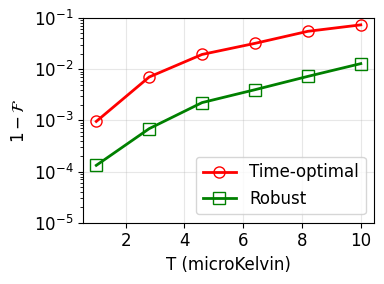

In [14]:
Tlist=np.linspace(1e-6,1e-5,6)
fig, ax = plt.subplots(figsize=(4, 3))
plt.rcParams.update({'font.size': 12})
plt.rcParams['lines.linewidth'] = 2
# Plot the first series

ax.plot(Tlist*1e6, FTOTdep480D, label='Time-optimal', color='red', marker='o', mfc='none', markersize=8)
# Plot the third series
ax.plot(Tlist*1e6, RobustTdep480D, label='Robust', color='green', marker='s', mfc='none', markersize=8)


# Add labels, title, and a legend for clarity
ax.set_xlabel("T (microKelvin)")
ax.set_ylabel(r"$1-\mathcal{F}$")
ax.set_yscale('log')
ax.set_ylim(1e-5,1e-1)
ax.legend() # Displays the labels defined in the scatter calls
fig.tight_layout()
ax.grid(alpha=0.3)
plt.savefig('RobustnessMonteCarlo480D.svg', format='svg')
# Display the plot
plt.show()

**Monte-Carlo simulation for two-photon Rydberg excitation at 420 nm and 1013 nm with Doppler**

***Amplitude-robust***

In [ ]:
w0=1e-6 #beam waist in meters
lam=850e-9 #trap wavelength
z0=np.pi*(w0**2)/lam
cl= 299792458 #light velocity m/s
kB=1.380649e-23 #Boltzmann constant
MRb=87*1.660539e-27 #Rb 87 mass  
U0=1e-4 #trap potential
wr=np.sqrt(4*kB*U0/(MRb*w0**2)) #radial trap frequency in kHz
wz=np.sqrt(2*kB*U0/(MRb*z0**2)) #axial trap frequency in kHz
d=22.662134135960255
pulse_ansatz_to = ro.pulses.PulseAnsatz(detuning_ansatz=ro.pulses.const,
                                        phase_ansatz=ro.pulses.lin_sin_cos_crab,
                                        rabi_ansatz=ro.pulses.softbox_seventh_order_smoothstep)
initial_params  =  (1, [0.40433569*d], [0.01959632*d, 0.80582318, -1.29913162, 0.24595796, 1.75011831, 0.06425968, -0.15430385, 0.10287453, -0.18786168, -0.1484231, 0.2266793, -0.02549104, -0.6134942, 0.8116914, 0.10364234, -0.34698707, -0.57748581, -0.11806264, 0.50882035, -0.2240126, -0.58173406], [0.99964949*d , 0.25690718])
Tlist=np.linspace(1e-6,1e-5,6)
rng = np.random.default_rng()
RobustTdep420D=[]
N = 200 #data size

for j in range(len(Tlist)):
    T=Tlist[j] #list of temperatures
    sigma_xy=np.sqrt(kB*T/(MRb*wr**2))  #x and y spread
    sigma_z=np.sqrt(kB*T/(MRb*wz**2)) #z spread
    sigma_v=np.sqrt(kB*T/(MRb)) # velocity spread

    
    t = rng.uniform(0, 2*np.pi/omega_z, size=(N, 2))  #time points during one cycle of trap motion
    # Initial conditions for two atoms (2) for N shots
    x0  = rng.normal(0.0, sigma_xy, size=(N, 2))
    y0  = rng.normal(0.0, sigma_xy, size=(N, 2))
    z0  = rng.normal(0.0, sigma_z,  size=(N, 2))
    vx0 = rng.normal(0.0, sigma_v,  size=(N, 2))
    vy0 = rng.normal(0.0, sigma_v,  size=(N, 2))
    vz0 = rng.normal(0.0, sigma_v,  size=(N, 2))

    # Harmonic evolution (analytic)
    cr, sr = np.cos(wr * t), np.sin(wr * t)
    cz, sz = np.cos(wz * t), np.sin(wz * t)

    x  = x0 * cr + (vx0 / wr) * sr
    y  = y0 * cr + (vy0 / wr) * sr
    z  = z0 * cz + (vz0 / wz) * sz
    vz = -z0 *wz * sz + vz0 * cz

    r = np.sqrt(x*x + y*y)

    Radial1 = r[:, 0]
    Axial1 = z[:, 0]
    Radial2 = r[:, 1]
    Axial2 = z[:, 1]
    Vz1= vz[:, 0]
    Vz2= vz[:, 1]
    Doppler1=Vz1*1e-6*2*np.pi*(1/(420e-9)-1/(1013e-9)) 
    Doppler2=Vz2*1e-6*2*np.pi*(1/(420e-9)-1/(1013e-9)) 
    
    ScalingP1=Rabi(Radial1,Axial1,1013e-9)
    ScalingS1=Rabi(Radial1,Axial1,420e-9)
    ScalingP2=Rabi(Radial2,Axial2,1013e-9)
    ScalingS2=Rabi(Radial2,Axial2,420e-9)

    Detuning1=(initial_params[1]+Doppler1)/initial_params[1]
    Detuning2=(initial_params[1]+Doppler2)/initial_params[1]
    FRobustT=[]
    print("j= %.i " % j)
    for i in range(len(ScalingP1)):
        gate = CZGateTwoPhotonAsymm(2*np.pi*5000,2*np.pi*5000,s1=ScalingS1[i] ,s2=ScalingS2[i],p1=ScalingP1[i] ,p2=ScalingP2[i],f1= Detuning1[i],f2= Detuning2[i])
        pulse_params  = initial_params[0],initial_params[1],initial_params[2],initial_params[3],
        time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz_to, pulse_params)
        FRobustT.append(1-gate.process_fidelity(time_evolved_basis_states).item())
        print(i)
    RobustTdep420D.append(np.mean(FRobustT).item())
RobustTdep420D

In [16]:
RobustTdep420D=[0.00035328484293430774,
 0.002567599691692655,
 0.007021543083789582,
 0.013450544351624303,
 0.01740068265224868,
 0.03586752241974258]

***Smooth time optimal***

In [ ]:
w0=1e-6 #beam waist in meters
lam=850e-9 #trap wavelength
z0=np.pi*(w0**2)/lam
cl= 299792458 #light velocity m/s
kB=1.380649e-23 #Boltzmann constant
MRb=87*1.660539e-27 #Rb 87 mass  
U0=1e-4 #trap potential
wr=np.sqrt(4*kB*U0/(MRb*w0**2)) #radial trap frequency in kHz
wz=np.sqrt(2*kB*U0/(MRb*z0**2)) #axial trap frequency in kHz
pulse_ansatz = ro.pulses.PulseAnsatz(
    detuning_ansatz=ro.pulses.const,
    phase_ansatz=ro.pulses.sin_crab,
    rabi_ansatz=ro.pulses.softbox_seventh_order_smoothstep,
)
d=4.058348807763706
initial_params=(1, [-0.09393892*d ], [0.73884332, 0.77225565], [2.09722135*d , 0.19713572])
Tlist=np.linspace(1e-6,1e-5,6)
rng = np.random.default_rng()
FTOTdep420D=[]
N = 200 #data size

for j in range(len(Tlist)):
    T=Tlist[j] #list of temperatures
    sigma_xy=np.sqrt(kB*T/(MRb*wr**2))  #x and y spread
    sigma_z=np.sqrt(kB*T/(MRb*wz**2)) #z spread
    sigma_v=np.sqrt(kB*T/(MRb)) # velocity spread

    
    t = rng.uniform(0, 2*np.pi/omega_z, size=(N, 2))  #time points during one cycle of trap motion
    # Initial conditions for two atoms (2) for N shots
    x0  = rng.normal(0.0, sigma_xy, size=(N, 2))
    y0  = rng.normal(0.0, sigma_xy, size=(N, 2))
    z0  = rng.normal(0.0, sigma_z,  size=(N, 2))
    vx0 = rng.normal(0.0, sigma_v,  size=(N, 2))
    vy0 = rng.normal(0.0, sigma_v,  size=(N, 2))
    vz0 = rng.normal(0.0, sigma_v,  size=(N, 2))

    # Harmonic evolution (analytic)
    cr, sr = np.cos(wr * t), np.sin(wr * t)
    cz, sz = np.cos(wz * t), np.sin(wz * t)

    x  = x0 * cr + (vx0 / wr) * sr
    y  = y0 * cr + (vy0 / wr) * sr
    z  = z0 * cz + (vz0 / wz) * sz
    vz = -z0 *wz * sz + vz0 * cz

    r = np.sqrt(x*x + y*y)

    Radial1 = r[:, 0]
    Axial1 = z[:, 0]
    Radial2 = r[:, 1]
    Axial2 = z[:, 1]
    Vz1= vz[:, 0]
    Vz2= vz[:, 1]
    Doppler1=Vz1*1e-6*2*np.pi*(1/(420e-9)-1/(1013e-9)) 
    Doppler2=Vz2*1e-6*2*np.pi*(1/(420e-9)-1/(1013e-9)) 
    
    ScalingP1=Rabi(Radial1,Axial1,1013e-9)
    ScalingS1=Rabi(Radial1,Axial1,420e-9)
    ScalingP2=Rabi(Radial2,Axial2,1013e-9)
    ScalingS2=Rabi(Radial2,Axial2,420e-9)

    Detuning1=(initial_params[1]+Doppler1)/initial_params[1]
    Detuning2=(initial_params[1]+Doppler2)/initial_params[1]
    FRobustT=[]
    print("j= %.i " % j)
    for i in range(len(ScalingP1)):
        gate = CZGateTwoPhotonAsymm(2*np.pi*5000,2*np.pi*5000,s1=ScalingS1[i] ,s2=ScalingS2[i],p1=ScalingP1[i] ,p2=ScalingP2[i],f1= Detuning1[i],f2= Detuning2[i])
        pulse_params  = initial_params[0],initial_params[1],initial_params[2],initial_params[3],
        time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz, pulse_params)
        FRobustT.append(1-gate.process_fidelity(time_evolved_basis_states).item())
        print(i)
    FTOTdep420D.append(np.mean(FRobustT).item())
FTOTdep420D

In [17]:
FTOTdep420D=[0.0012997006027061896,
 0.008237022006194418,
 0.021118745484817972,
 0.04026488333942791,
 0.05268997602696286,
 0.09035826511075092]

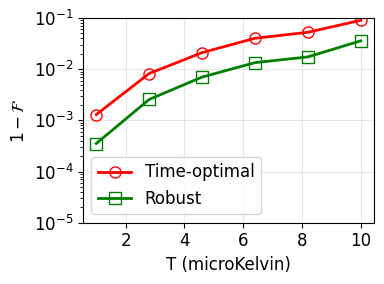

In [18]:
Tlist=np.linspace(1e-6,1e-5,6)
fig, ax = plt.subplots(figsize=(4, 3))
plt.rcParams.update({'font.size': 12})
plt.rcParams['lines.linewidth'] = 2
# Plot the first series

ax.plot(Tlist*1e6, FTOTdep420D, label='Time-optimal', color='red', marker='o', mfc='none', markersize=8)
# Plot the third series
ax.plot(Tlist*1e6, RobustTdep420D, label='Robust', color='green', marker='s', mfc='none', markersize=8)


# Add labels, title, and a legend for clarity
ax.set_xlabel("T (microKelvin)")
ax.set_ylabel(r"$1-\mathcal{F}$")
ax.set_yscale('log')
ax.set_ylim(1e-5,1e-1)
ax.legend() # Displays the labels defined in the scatter calls
fig.tight_layout()
ax.grid(alpha=0.3)
plt.savefig('RobustnessMonteCarlo420D.svg', format='svg')
# Display the plot
plt.show()

**Monte-Carlo simulation for 480 nm and 780 nm depending on trap intensity**

In [ ]:
w0=1e-6 #beam waist in meters
lam=850e-9 #trap wavelength
z0=np.pi*(w0**2)/lam
cl= 299792458 #light velocity m/s
kB=1.380649e-23 #Boltzmann constant
MRb=87*1.660539e-27 #Rb 87 mass  

d=22.662134135960255
pulse_ansatz_to = ro.pulses.PulseAnsatz(detuning_ansatz=ro.pulses.const,
                                        phase_ansatz=ro.pulses.lin_sin_cos_crab,
                                        rabi_ansatz=ro.pulses.softbox_seventh_order_smoothstep)
initial_params  =  (1, [0.40433569*d], [0.01959632*d, 0.80582318, -1.29913162, 0.24595796, 1.75011831, 0.06425968, -0.15430385, 0.10287453, -0.18786168, -0.1484231, 0.2266793, -0.02549104, -0.6134942, 0.8116914, 0.10364234, -0.34698707, -0.57748581, -0.11806264, 0.50882035, -0.2240126, -0.58173406], [0.99964949*d , 0.25690718])
Tlist=np.linspace(1e-6,1e-5,6)
rng = np.random.default_rng()
RobustUdep480D=[]
N = 200 #data size
Ulist=np.linspace(5e-5,5e-4,6)
for j in range(len(Tlist)):
    U0=Ulist[j]
    T=5e-6
    wr=np.sqrt(4*kB*U0/(MRb*w0**2)) #radial trap frequency in kHz
    wz=np.sqrt(2*kB*U0/(MRb*z0**2)) #axial trap frequency in kHz
    sigma_xy=np.sqrt(kB*T/(MRb*wr**2))  #x and y spread
    sigma_z=np.sqrt(kB*T/(MRb*wz**2)) #z spread
    sigma_v=np.sqrt(kB*T/(MRb)) # velocity spread

    
    t = rng.uniform(0, 2*np.pi/omega_z, size=(N, 2))  #time points during one cycle of trap motion
    # Initial conditions for two atoms (2) for N shots
    x0  = rng.normal(0.0, sigma_xy, size=(N, 2))
    y0  = rng.normal(0.0, sigma_xy, size=(N, 2))
    z0  = rng.normal(0.0, sigma_z,  size=(N, 2))
    vx0 = rng.normal(0.0, sigma_v,  size=(N, 2))
    vy0 = rng.normal(0.0, sigma_v,  size=(N, 2))
    vz0 = rng.normal(0.0, sigma_v,  size=(N, 2))

    # Harmonic evolution (analytic)
    cr, sr = np.cos(wr * t), np.sin(wr * t)
    cz, sz = np.cos(wz * t), np.sin(wz * t)

    x  = x0 * cr + (vx0 / wr) * sr
    y  = y0 * cr + (vy0 / wr) * sr
    z  = z0 * cz + (vz0 / wz) * sz
    vz = -z0 *wz * sz + vz0 * cz

    r = np.sqrt(x*x + y*y)

    Radial1 = r[:, 0]
    Axial1 = z[:, 0]
    Radial2 = r[:, 1]
    Axial2 = z[:, 1]
    Vz1= vz[:, 0]
    Vz2= vz[:, 1]
    Doppler1=Vz1*1e-6*2*np.pi*(1/(480e-9)-1/(780e-9)) 
    Doppler2=Vz2*1e-6*2*np.pi*(1/(480e-9)-1/(780e-9)) 
    
    ScalingP1=Rabi(Radial1,Axial1,780e-9)
    ScalingS1=Rabi(Radial1,Axial1,480e-9)
    ScalingP2=Rabi(Radial2,Axial2,780e-9)
    ScalingS2=Rabi(Radial2,Axial2,480e-9)

    Detuning1=(initial_params[1]+Doppler1)/initial_params[1]
    Detuning2=(initial_params[1]+Doppler2)/initial_params[1]
    FRobustT=[]
    print("j= %.i " % j)
    for i in range(len(ScalingP1)):
        gate = CZGateTwoPhotonAsymm(2*np.pi*5000,2*np.pi*5000,s1=ScalingS1[i] ,s2=ScalingS2[i],p1=ScalingP1[i] ,p2=ScalingP2[i],f1= Detuning1[i],f2= Detuning2[i])
        pulse_params  = initial_params[0],initial_params[1],initial_params[2],initial_params[3],
        time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz_to, pulse_params)
        FRobustT.append(1-gate.process_fidelity(time_evolved_basis_states).item())
        print(i)
    RobustUdep480D.append(np.mean(FRobustT).item())
RobustUdep480D

In [19]:
RobustUdep480D=[0.010565744610694892,
 0.00039737637883729027,
 0.00027503211426044115,
 0.0002756709943659419,
 0.0002933339529502316,
 0.00027515071435020577]

In [ ]:
w0=1e-6 #beam waist in meters
lam=850e-9 #trap wavelength
z0=np.pi*(w0**2)/lam
cl= 299792458 #light velocity m/s
kB=1.380649e-23 #Boltzmann constant
MRb=87*1.660539e-27 #Rb 87 mass  

pulse_ansatz = ro.pulses.PulseAnsatz(
    detuning_ansatz=ro.pulses.const,
    phase_ansatz=ro.pulses.sin_crab,
    rabi_ansatz=ro.pulses.softbox_seventh_order_smoothstep,
)
d=4.058348807763706
initial_params=(1, [-0.09393892*d ], [0.73884332, 0.77225565], [2.09722135*d , 0.19713572])

Tlist=np.linspace(1e-6,1e-5,6)
rng = np.random.default_rng()
TOTUdep480D=[]
N = 200 #data size
Ulist=np.linspace(5e-5,5e-4,6)
for j in range(len(Tlist)):
    U0=Ulist[j]
    T=5e-6
    wr=np.sqrt(4*kB*U0/(MRb*w0**2)) #radial trap frequency in kHz
    wz=np.sqrt(2*kB*U0/(MRb*z0**2)) #axial trap frequency in kHz
    sigma_xy=np.sqrt(kB*T/(MRb*wr**2))  #x and y spread
    sigma_z=np.sqrt(kB*T/(MRb*wz**2)) #z spread
    sigma_v=np.sqrt(kB*T/(MRb)) # velocity spread

    
    t = rng.uniform(0, 2*np.pi/omega_z, size=(N, 2))  #time points during one cycle of trap motion
    # Initial conditions for two atoms (2) for N shots
    x0  = rng.normal(0.0, sigma_xy, size=(N, 2))
    y0  = rng.normal(0.0, sigma_xy, size=(N, 2))
    z0  = rng.normal(0.0, sigma_z,  size=(N, 2))
    vx0 = rng.normal(0.0, sigma_v,  size=(N, 2))
    vy0 = rng.normal(0.0, sigma_v,  size=(N, 2))
    vz0 = rng.normal(0.0, sigma_v,  size=(N, 2))

    # Harmonic evolution (analytic)
    cr, sr = np.cos(wr * t), np.sin(wr * t)
    cz, sz = np.cos(wz * t), np.sin(wz * t)

    x  = x0 * cr + (vx0 / wr) * sr
    y  = y0 * cr + (vy0 / wr) * sr
    z  = z0 * cz + (vz0 / wz) * sz
    vz = -z0 *wz * sz + vz0 * cz

    r = np.sqrt(x*x + y*y)

    Radial1 = r[:, 0]
    Axial1 = z[:, 0]
    Radial2 = r[:, 1]
    Axial2 = z[:, 1]
    Vz1= vz[:, 0]
    Vz2= vz[:, 1]
    Doppler1=Vz1*1e-6*2*np.pi*(1/(480e-9)-1/(780e-9)) 
    Doppler2=Vz2*1e-6*2*np.pi*(1/(480e-9)-1/(780e-9)) 
    
    ScalingP1=Rabi(Radial1,Axial1,780e-9)
    ScalingS1=Rabi(Radial1,Axial1,480e-9)
    ScalingP2=Rabi(Radial2,Axial2,780e-9)
    ScalingS2=Rabi(Radial2,Axial2,480e-9)

    Detuning1=(initial_params[1]+Doppler1)/initial_params[1]
    Detuning2=(initial_params[1]+Doppler2)/initial_params[1]
    FRobustT=[]
    print("j= %.i " % j)
    for i in range(len(ScalingP1)):
        gate = CZGateTwoPhotonAsymm(2*np.pi*5000,2*np.pi*5000,s1=ScalingS1[i] ,s2=ScalingS2[i],p1=ScalingP1[i] ,p2=ScalingP2[i],f1= Detuning1[i],f2= Detuning2[i])
        pulse_params  = initial_params[0],initial_params[1],initial_params[2],initial_params[3],
        time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz, pulse_params)
        errF=1-gate.process_fidelity(time_evolved_basis_states).item()
        FRobustT.append(errF)
        print(i,errF)
    TOTUdep480D.append(np.mean(FRobustT).item())
TOTUdep480D

In [20]:
TOTUdep480D=[0.06458257059072078,
 0.007441058845246311,
 0.0027889829780712943,
 0.0019199604441631313,
 0.001490868341455815,
 0.0012317744482268312]

**Dependence on trap intensity**

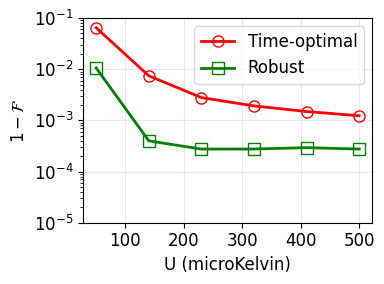

In [22]:
Ulist=np.linspace(5e-5,5e-4,6)
fig, ax = plt.subplots(figsize=(4, 3))
plt.rcParams.update({'font.size': 12})
plt.rcParams['lines.linewidth'] = 2
# Plot the first series

ax.plot(Ulist*1e6, TOTUdep480D, label='Time-optimal', color='red', marker='o', mfc='none', markersize=8)
# Plot the third series
ax.plot(Ulist*1e6, RobustUdep480D, label='Robust', color='green', marker='s', mfc='none', markersize=8)


# Add labels, title, and a legend for clarity
ax.set_xlabel("U (microKelvin)")
ax.set_ylabel(r"$1-\mathcal{F}$")
ax.set_yscale('log')
ax.set_ylim(1e-5,1e-1)
ax.legend() # Displays the labels defined in the scatter calls
fig.tight_layout()
ax.grid(alpha=0.3)
plt.savefig('RobustnessMonteCarloU480.svg', format='svg')
# Display the plot
plt.show()